In [ ]:
#pull in basefile

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:

bf = pd.read_parquet("E:\\tfl_project\cell_day_with_tube_features.parquet")

bf.head()

,h3_cell,day,total_trips,n_stations,frac_exposed,temperature_2m,relative_humidity_2m,precipitation,rain,doy,...,y_per_station_log1p,dist_nearest_tube_km,n_tube_within_500m,n_tube_within_1000m,n_tube_within_2000m,y_log1p,tube_disruption_approx,D_continuous,date_str,treated
0,88194ad101fffff,2016-01-10,42,1,0,6.392308,80.307692,0.000000,0.000000,10,...,3.761200,1.759696,0,0,2,3.761200,0.0,0.0,2016-01-10,0
1,88194ad101fffff,2016-01-11,46,2,0,5.753846,91.538462,0.169231,0.169231,11,...,3.178054,1.759696,0,0,2,3.850148,0.0,0.0,2016-01-11,0
2,88194ad101fffff,2016-01-12,39,3,0,4.790909,80.363636,0.036364,0.036364,12,...,2.639057,1.759696,0,0,2,3.688879,0.0,0.0,2016-01-12,0
3,88194ad101fffff,2016-01-13,58,1,0,3.573333,81.933333,0.000000,0.000000,13,...,4.077537,1.759696,0,0,2,4.077537,0.0,0.0,2016-01-13,0
4,88194ad101fffff,2016-01-14,59,1,0,2.535294,76.647059,0.029412,0.029412,14,...,4.094345,1.759696,0,0,2,4.094345,0.0,0.0,2016-01-14,0


In [ ]:

# Use your final dataset name here:
df = bf.copy()

df["date"] = df["day"].dt.floor("D")
df["week"] = df["day"].dt.to_period("W").dt.start_time
df["month"] = df["day"].dt.to_period("M").dt.start_time
df["dow"] = df["day"].dt.dayofweek
df["hour"] = df["day"].dt.hour
df["hour_of_week"] = df["dow"] * 24 + df["hour"]


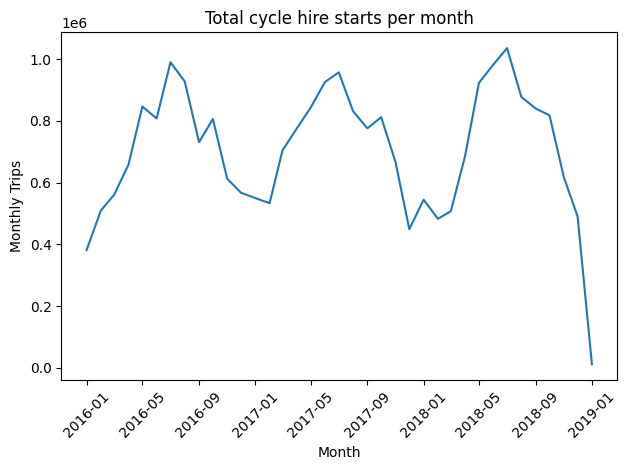

In [14]:
daily = df.groupby("month", as_index=False)["total_trips"].sum().sort_values("month")

plt.figure()
plt.plot(daily["month"], daily["total_trips"])
plt.title("Total cycle hire starts per month")
plt.xlabel("Month")
plt.ylabel("Monthly Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

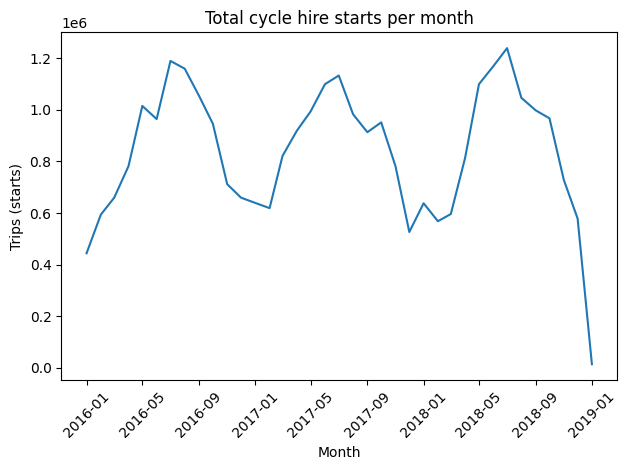

In [10]:
monthly = df.groupby("month", as_index=False)["trips_start"].sum().sort_values("month")

plt.figure()
plt.plot(monthly["month"], monthly["trips_start"])
plt.title("Total cycle hire starts per month")
plt.xlabel("Month")
plt.ylabel("Trips (starts)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

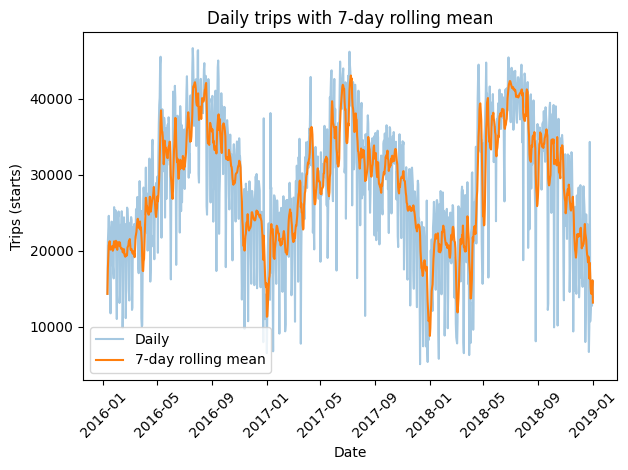

In [11]:
daily2 = daily.copy()
daily2["roll7"] = daily2["trips_start"].rolling(7, min_periods=1).mean()

plt.figure()
plt.plot(daily2["date"], daily2["trips_start"], alpha=0.4, label="Daily")
plt.plot(daily2["date"], daily2["roll7"], label="7-day rolling mean")
plt.title("Daily trips with 7-day rolling mean")
plt.xlabel("Date")
plt.ylabel("Trips (starts)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

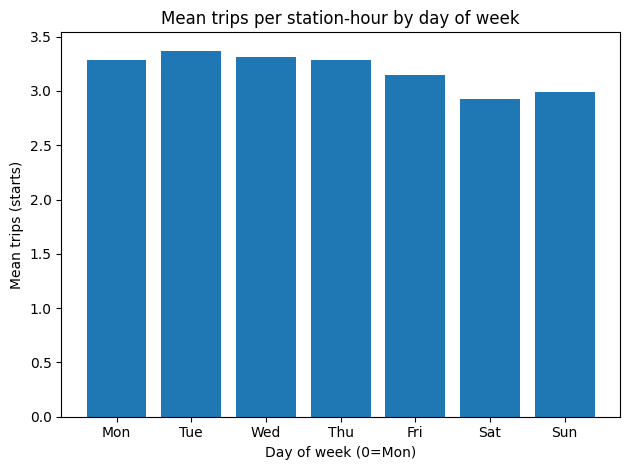

In [12]:
dow_avg = df.groupby("dow", as_index=False)["trips_start"].mean().sort_values("dow")

plt.figure()
plt.bar(dow_avg["dow"], dow_avg["trips_start"])
plt.title("Mean trips per station-hour by day of week")
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Mean trips (starts)")
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.tight_layout()
plt.show()

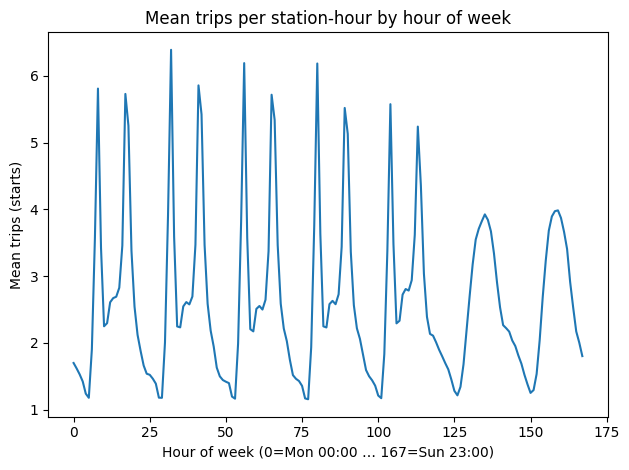

In [13]:
how_avg = df.groupby("hour_of_week", as_index=False)["trips_start"].mean().sort_values("hour_of_week")

plt.figure()
plt.plot(how_avg["hour_of_week"], how_avg["trips_start"])
plt.title("Mean trips per station-hour by hour of week")
plt.xlabel("Hour of week (0=Mon 00:00 … 167=Sun 23:00)")
plt.ylabel("Mean trips (starts)")
plt.tight_layout()
plt.show()

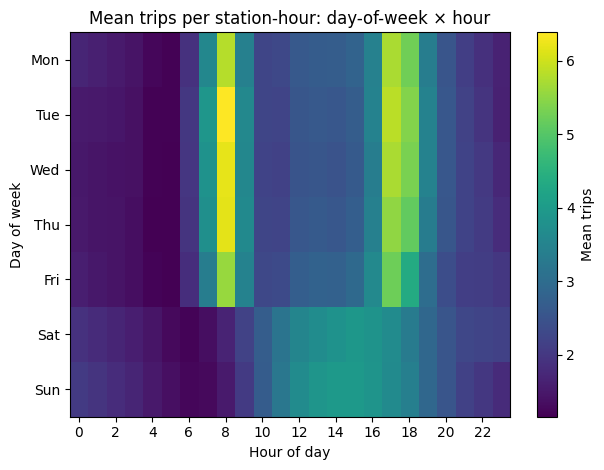

In [14]:
heat = (
    df.groupby(["dow", "hour"], as_index=False)["trips_start"]
    .mean()
    .pivot(index="dow", columns="hour", values="trips_start")
)

plt.figure()
plt.imshow(heat.values, aspect="auto")
plt.title("Mean trips per station-hour: day-of-week × hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.colorbar(label="Mean trips")
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xticks(range(0,24,2), range(0,24,2))
plt.tight_layout()
plt.show()

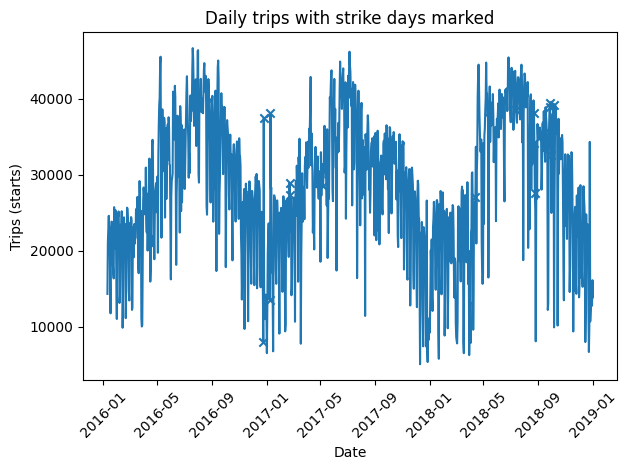

In [15]:
if "strike_exposed" in df.columns:
    day_flag = df.groupby("date", as_index=False)["strike_exposed"].max()
    daily_flagged = daily.merge(day_flag, on="date", how="left").fillna({"strike_exposed": 0})

    plt.figure()
    plt.plot(daily_flagged["date"], daily_flagged["trips_start"])
    strike_days = daily_flagged[daily_flagged["strike_exposed"] == 1]
    plt.scatter(strike_days["date"], strike_days["trips_start"], marker="x")
    plt.title("Daily trips with strike days marked")
    plt.xlabel("Date")
    plt.ylabel("Trips (starts)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
if "strike_exposed" in df.columns:
    daily_flagged = daily_flagged.copy()
    strike = daily_flagged[daily_flagged["strike_exposed"] == 1]["trips_start"]
    nostrike = daily_flagged[daily_flagged["strike_exposed"] == 0]["trips_start"]

    plt.figure()
    plt.hist(strike, bins=40, alpha=0.7, label="Strike days")
    plt.hist(nostrike, bins=40, alpha=0.7, label="Non-strike days")
    plt.title("Distribution of total daily trips")
    plt.xlabel("Total trips per day")
    plt.ylabel("Count of days")
    plt.legend()
    plt.tight_layout()
    plt.show()

: 